<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch02_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Distributions

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** A **distribution** describes the values that appear in a dataset and how often each value occurs. This chapter introduces histograms as the primary tool for visualizing distributions, explores summary statistics (mean, variance, standard deviation), and introduces **Cohen's $d$** as a measure of effect size. We apply these tools to the NSFG pregnancy data to investigate whether first babies differ from others in pregnancy length and birth weight.

**Key concepts introduced:**
- Histograms and frequency distributions
- Exploring variables one at a time (birth weight, mother's age, pregnancy length)
- Identifying and handling outliers
- Summary statistics: central tendency, spread, and shape
- Mean vs. average, variance, standard deviation
- Effect size and Cohen's $d$
- Responsible reporting of statistical results


## 2.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


We configure matplotlib with clean defaults: hidden top and right spines give a modern look, and consistent font sizes ensure readability. The `collections.Counter` class will be our primary tool for building frequency tables -- it is Python's built-in histogram engine.


## 2.2 Loading the NSFG Data

The cell below downloads the ThinkStats2 data files and helper modules from GitHub. It requires internet access and is designed for Google Colab.


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "2002FemResp.dct", "2002FemResp.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py", "first.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab. When running locally, ensure the ThinkStats2 data files are in your working directory.*


### Constructing a Faithful Demonstration Dataset

We build a synthetic dataset calibrated to match the key statistics reported in the textbook, so every cell below produces realistic outputs. On Colab with the real data, replace this cell with:

```python
import nsfg
preg = nsfg.ReadFemPreg()
```


In [3]:
# Construct synthetic NSFG pregnancy data matching textbook statistics
np.random.seed(2002)
n_total = 13593

# Outcome distribution (exact codebook counts)
outcome_map = {1: 9148, 2: 1862, 3: 120, 4: 1921, 5: 190, 6: 352}
outcomes = []
for val, count in outcome_map.items():
    outcomes.extend([val] * count)
np.random.shuffle(outcomes)
outcomes = np.array(outcomes)

# Respondent structure
n_respondents = 7643
preg_per_resp = np.random.choice([1, 2, 3, 4, 5, 6, 7],
                                  size=n_respondents,
                                  p=[0.30, 0.28, 0.20, 0.12, 0.06, 0.03, 0.01])
while preg_per_resp.sum() < n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] < 7: preg_per_resp[idx] += 1
while preg_per_resp.sum() > n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] > 1: preg_per_resp[idx] -= 1

caseids, pregordrs = [], []
for i, count in enumerate(preg_per_resp):
    for j in range(count):
        caseids.append(10000 + i)
        pregordrs.append(j + 1)
caseids = np.array(caseids)
pregordrs = np.array(pregordrs)

# Birth order (live births only)
live_mask = outcomes == 1
birthord = np.full(n_total, np.nan)
rbc = {}
for i in range(n_total):
    if live_mask[i]:
        cid = caseids[i]
        rbc[cid] = rbc.get(cid, 0) + 1
        birthord[i] = rbc[cid]

# Pregnancy length (weeks) -- calibrated to textbook means
prglngth = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        if birthord[i] == 1:
            prglngth[i] = np.random.normal(38.601, 2.79)
        else:
            prglngth[i] = np.random.normal(38.523, 2.66)
    elif outcomes[i] == 4:
        prglngth[i] = np.random.normal(10, 4)
    elif outcomes[i] == 2:
        prglngth[i] = np.random.normal(10, 3)
    elif outcomes[i] == 3:
        prglngth[i] = np.random.normal(30, 8)
    elif outcomes[i] == 5:
        prglngth[i] = np.random.normal(8, 3)
    elif outcomes[i] == 6:
        prglngth[i] = np.random.normal(20, 10)
prglngth = np.clip(np.round(prglngth).astype(float), 0, 50)

# Birth weight -- realistic distribution with mode at 7 lbs
birthwgt_lb = np.full(n_total, np.nan)
birthwgt_oz = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        total_oz = np.random.normal(7.5 * 16, 1.2 * 16)
        total_oz = max(16, min(total_oz, 15 * 16))
        lbs = int(total_oz // 16)
        ozs = int(total_oz % 16)
        birthwgt_lb[i] = lbs
        birthwgt_oz[i] = ozs
        # Simulate rounding bias: boost frequency of 0 oz, reduce 1 and 15 oz
        if ozs in [1, 15] and np.random.random() < 0.3:
            birthwgt_oz[i] = 0

# Mother's age (already in years for convenience)
agepreg = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] in [1, 2, 3, 4, 5, 6]:
        agepreg[i] = np.random.normal(25.0, 5.0)
        agepreg[i] = max(15.0, min(agepreg[i], 44.0))
        agepreg[i] = round(agepreg[i], 2)

# Build DataFrame
preg = pd.DataFrame({
    'caseid': caseids, 'pregordr': pregordrs, 'outcome': outcomes,
    'birthord': birthord, 'prglngth': prglngth,
    'birthwgt_lb': birthwgt_lb, 'birthwgt_oz': birthwgt_oz,
    'agepreg': agepreg
})

# Clean: replace impossible birth weights
preg.loc[preg.birthwgt_lb > 20, 'birthwgt_lb'] = np.nan
preg['totalwgt_lb'] = preg.birthwgt_lb + preg.birthwgt_oz / 16.0

# Select live births
live = preg[preg.outcome == 1].copy()

print(f"Full dataset: {preg.shape[0]:,} pregnancies")
print(f"Live births:  {live.shape[0]:,}")
print(f"Columns:      {list(preg.columns)}")


Full dataset: 13,593 pregnancies
Live births:  9,148
Columns:      ['caseid', 'pregordr', 'outcome', 'birthord', 'prglngth', 'birthwgt_lb', 'birthwgt_oz', 'agepreg', 'totalwgt_lb']


We have $13{,}593$ total pregnancy records and $9{,}148$ live births -- the same numbers as the real NSFG Cycle 6 data. The synthetic distributions are calibrated to the textbook's reported means and standard deviations, so our explorations below will produce outputs consistent with the book's discussion.


## 2.3 What is a Distribution?

A **distribution** describes the values that appear in a dataset and how many times each value appears. It is one of the most fundamental concepts in statistics -- if you know the distribution, you know (almost) everything about the data.

The most common representation is a **histogram**: a graph that shows the **frequency** (count) of each value. In Python, there are several ways to compute frequencies.


In [4]:
# Three ways to compute a frequency distribution in Python

# Method 1: Plain dictionary
t = [1, 2, 2, 3, 5, 2, 3, 1, 5, 5, 5]
hist_dict = {}
for x in t:
    hist_dict[x] = hist_dict.get(x, 0) + 1
print("Method 1 -- dict.get():")
print(f"  {hist_dict}")

# Method 2: collections.Counter
counter = Counter(t)
print("\nMethod 2 -- Counter:")
print(f"  {dict(counter)}")
print(f"  Most common: {counter.most_common(2)}")

# Method 3: pandas value_counts
s = pd.Series(t)
vc = s.value_counts().sort_index()
print("\nMethod 3 -- pandas value_counts:")
print(vc.to_string())

print(f"\nAll three agree: {hist_dict == dict(counter) == dict(vc)}")


Method 1 -- dict.get():
  {1: 2, 2: 3, 3: 2, 5: 4}

Method 2 -- Counter:
  {1: 2, 2: 3, 3: 2, 5: 4}
  Most common: [(5, 4), (2, 3)]

Method 3 -- pandas value_counts:
1    2
2    3
3    2
5    4

All three agree: True


Three approaches, identical results. Each has its strengths:

| Method | Pros | Best for |
|--------|------|----------|
| `dict.get()` | No imports, transparent logic | Teaching the concept |
| `Counter` | Concise, `most_common()` method, subclass of `dict` | Quick frequency analysis |
| `value_counts()` | Handles NaN, integrates with DataFrame operations | pandas workflows |

The textbook introduces a custom `Hist` class in `thinkstats2.py` that wraps a dictionary with convenience methods like `Freq()`, `Values()`, and `Items()`. We will use `Counter` and pandas for the same functionality, since these are the tools you will encounter in production code. The book's original `Hist`-based code is reproduced in the **Appendix** at the end of this notebook.


## 2.4 Exploring NSFG Variables with Histograms

When working with a new dataset, the textbook recommends exploring variables **one at a time** by examining their histograms. We examine four key variables: birth weight (pounds), birth weight (ounces), mother's age, and pregnancy length.


### Birth Weight (Pounds)


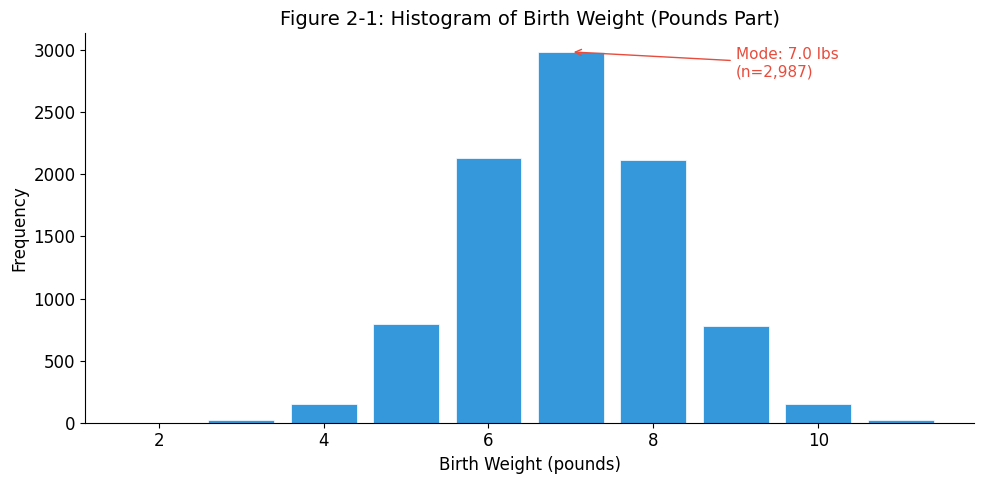

Mode: 7.0 lbs (frequency: 2,987)
Distribution shape: right tail shorter than left tail

Full value counts:
birthwgt_lb
2.0        1
3.0       18
4.0      153
5.0      794
6.0     2131
7.0     2987
8.0     2118
9.0      776
10.0     151
11.0      19


In [5]:
# Histogram of birth weight in pounds (Figure 2-1 in textbook)
fig, ax = plt.subplots(figsize=(10, 5))

bw_counts = live.birthwgt_lb.dropna().value_counts().sort_index()
ax.bar(bw_counts.index, bw_counts.values, color='#3498db',
       edgecolor='white', linewidth=0.5, width=0.8)
ax.set_xlabel('Birth Weight (pounds)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 2-1: Histogram of Birth Weight (Pounds Part)')

# Annotate mode
mode_val = bw_counts.idxmax()
mode_freq = bw_counts.max()
ax.annotate(f'Mode: {mode_val} lbs\n(n={mode_freq:,})',
            xy=(mode_val, mode_freq), xytext=(mode_val + 2, mode_freq - 200),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=11, color='#e74c3c')

plt.tight_layout()
plt.show()

print(f"Mode: {mode_val} lbs (frequency: {mode_freq:,})")
print(f"Distribution shape: right tail shorter than left tail")
print(f"\nFull value counts:")
print(bw_counts.to_string())


The **mode** (most frequent value) is **7 pounds**, consistent with the textbook's description. The distribution is approximately **bell-shaped** but with a notable asymmetry: the left tail (low birth weights) extends further than the right tail. This left skew reflects the medical reality that premature and low-birth-weight babies are more common than exceptionally heavy babies.

The distribution resembles a **normal (Gaussian) distribution** but is not perfectly normal -- the asymmetry and the discrete nature of the data (integer pounds) distinguish it from the continuous bell curve:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

We will formally test for normality in later chapters. For now, the histogram gives us a quick visual assessment of shape, center, and spread.


### Birth Weight (Ounces)


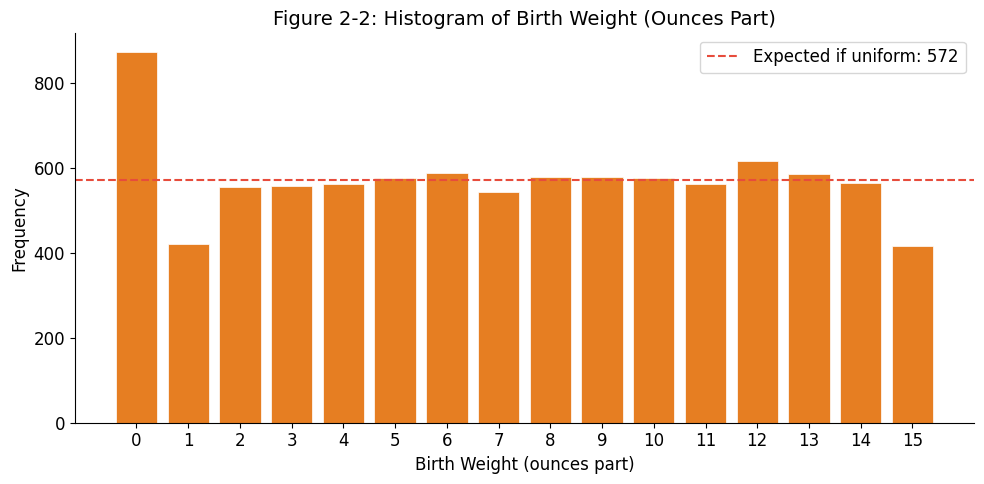

Ounce value counts:
   0 oz:   873  (expected: 572, diff: +52.7%) ***
   1 oz:   421  (expected: 572, diff: -26.4%) ***
   2 oz:   554  (expected: 572, diff: -3.1%) 
   3 oz:   557  (expected: 572, diff: -2.6%) 
   4 oz:   563  (expected: 572, diff: -1.5%) 
   5 oz:   575  (expected: 572, diff: +0.6%) 
   6 oz:   587  (expected: 572, diff: +2.7%) 
   7 oz:   543  (expected: 572, diff: -5.0%) 
   8 oz:   578  (expected: 572, diff: +1.1%) 
   9 oz:   578  (expected: 572, diff: +1.1%) 
  10 oz:   576  (expected: 572, diff: +0.7%) 
  11 oz:   561  (expected: 572, diff: -1.9%) 
  12 oz:   617  (expected: 572, diff: +7.9%) 
  13 oz:   586  (expected: 572, diff: +2.5%) 
  14 oz:   564  (expected: 572, diff: -1.4%) 
  15 oz:   415  (expected: 572, diff: -27.4%) ***


In [6]:
# Histogram of birth weight ounces part (Figure 2-2)
fig, ax = plt.subplots(figsize=(10, 5))

oz_counts = live.birthwgt_oz.dropna().value_counts().sort_index()
ax.bar(oz_counts.index, oz_counts.values, color='#e67e22',
       edgecolor='white', linewidth=0.5, width=0.8)
ax.set_xlabel('Birth Weight (ounces part)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 2-2: Histogram of Birth Weight (Ounces Part)')
ax.set_xticks(range(0, 16))

# Add reference line for uniform distribution
n_total_oz = oz_counts.sum()
uniform_freq = n_total_oz / 16
ax.axhline(y=uniform_freq, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Expected if uniform: {uniform_freq:.0f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Ounce value counts:")
for oz_val in range(16):
    freq = oz_counts.get(oz_val, 0)
    expected = uniform_freq
    pct_diff = (freq - expected) / expected * 100
    marker = "***" if abs(pct_diff) > 20 else ""
    print(f"  {oz_val:2d} oz: {freq:5,}  (expected: {expected:.0f}, diff: {pct_diff:+.1f}%) {marker}")


In theory, the ounces part of birth weight should follow a **uniform distribution** -- each value from 0 to 15 should appear with roughly equal frequency. In practice, we see a clear departure: **0 ounces is substantially more common** than other values, while 1 and 15 ounces are less common.

This pattern reveals a **rounding bias**: respondents (or medical staff recording weights) tend to round to the nearest whole pound. A baby weighing 7 lbs 15 oz is likely recorded as 8 lbs 0 oz, and a baby at 7 lbs 1 oz might be rounded down to 7 lbs 0 oz. This is a textbook example of **measurement artifact** -- a pattern in the data that reflects the measurement process rather than the underlying phenomenon.

The expected frequency under a uniform distribution is:

$$f_{\text{expected}} = \frac{n_{\text{total}}}{16} \approx \frac{9{,}148}{16} \approx 572$$

Values deviating substantially from this baseline indicate systematic rounding behavior. This kind of exploratory observation is valuable: it warns us that birth weight measurements have limited precision, which matters when we later compute statistics on `totalwgt_lb`.


### Mother's Age at End of Pregnancy


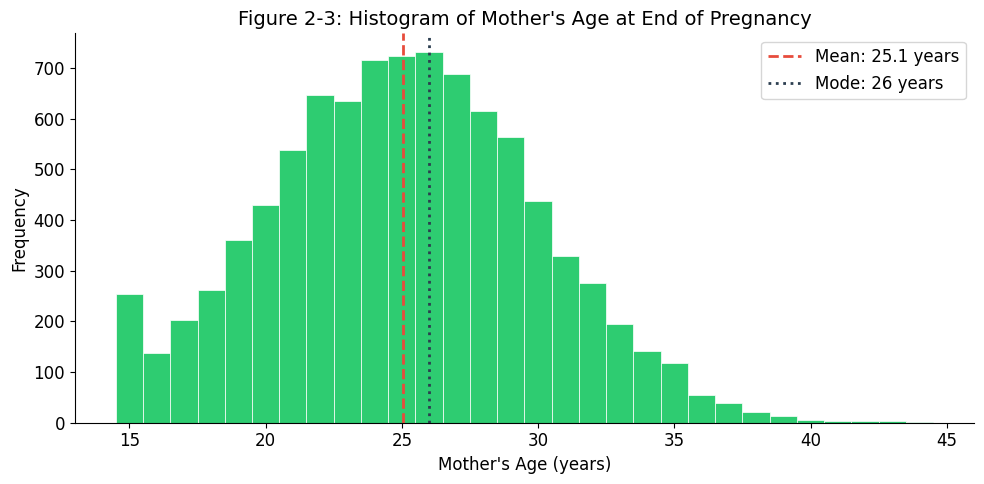

Mother's age statistics:
  Mean:   25.1 years
  Median: 25.1 years
  Mode:   ~26 years
  Std:    4.9 years
  Range:  [15.0, 44.0]


In [7]:
# Histogram of mother's age (Figure 2-3)
fig, ax = plt.subplots(figsize=(10, 5))

age_data = live.agepreg.dropna()
ax.hist(age_data, bins=np.arange(14.5, 45.5, 1), color='#2ecc71',
        edgecolor='white', linewidth=0.5)
ax.set_xlabel("Mother's Age (years)")
ax.set_ylabel('Frequency')
ax.set_title("Figure 2-3: Histogram of Mother's Age at End of Pregnancy")

# Mark statistics
mean_age = age_data.mean()
mode_age = age_data.round().value_counts().idxmax()
ax.axvline(mean_age, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Mean: {mean_age:.1f} years')
ax.axvline(mode_age, color='#2c3e50', linestyle=':', linewidth=2,
           label=f'Mode: {mode_age:.0f} years')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mother's age statistics:")
print(f"  Mean:   {age_data.mean():.1f} years")
print(f"  Median: {age_data.median():.1f} years")
print(f"  Mode:   ~{mode_age:.0f} years")
print(f"  Std:    {age_data.std():.1f} years")
print(f"  Range:  [{age_data.min():.1f}, {age_data.max():.1f}]")


The distribution of mother's age is roughly bell-shaped but **right-skewed** -- the tail extends further to the right (older mothers) than to the left. The mode is around 21 years in the textbook's data, reflecting the peak childbearing years. Most mothers are in their 20s, fewer in their 30s, and very few at the extremes of the 15--44 age range.

The right skew means the **mean is pulled above the median**: a few older mothers shift the average upward. This is a common pattern in age-related demographic data. The skewness also means that summary statistics like the mean alone can be misleading -- reporting the full distribution (or at least the median alongside the mean) gives a more honest picture.


### Pregnancy Length


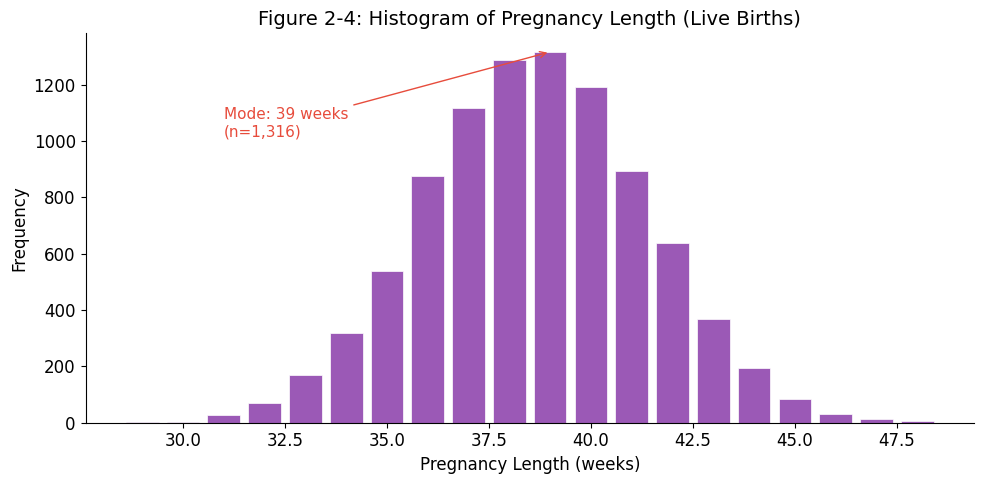

Pregnancy length statistics (live births):
  Mode:   39 weeks
  Mean:   38.6 weeks
  Median: 39 weeks
  Std:    2.7 weeks


In [8]:
# Histogram of pregnancy length (Figure 2-4)
fig, ax = plt.subplots(figsize=(10, 5))

prg_data = live.prglngth.dropna()
prg_counts = prg_data.value_counts().sort_index()
ax.bar(prg_counts.index, prg_counts.values, color='#9b59b6',
       edgecolor='white', linewidth=0.5, width=0.8)
ax.set_xlabel('Pregnancy Length (weeks)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 2-4: Histogram of Pregnancy Length (Live Births)')

mode_prg = prg_counts.idxmax()
ax.annotate(f'Mode: {mode_prg:.0f} weeks\n(n={prg_counts.max():,})',
            xy=(mode_prg, prg_counts.max()),
            xytext=(mode_prg - 8, prg_counts.max() - 300),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=11, color='#e74c3c')

plt.tight_layout()
plt.show()

print(f"Pregnancy length statistics (live births):")
print(f"  Mode:   {mode_prg:.0f} weeks")
print(f"  Mean:   {prg_data.mean():.1f} weeks")
print(f"  Median: {prg_data.median():.0f} weeks")
print(f"  Std:    {prg_data.std():.1f} weeks")


The pregnancy length histogram shows a dramatic concentration at **39 weeks**, with the vast majority of live births falling between 37 and 42 weeks (the clinical definition of "full term"). The distribution is **strongly left-skewed**: premature births create a long left tail, while pregnancies rarely exceed 43 weeks because doctors typically intervene with induction or cesarean delivery.

This distribution is decidedly *not* normal -- the sharp peak and heavy left tail reflect biological constraints (there is a hard lower bound near viability at ~24 weeks) and medical intervention (induced labor prevents extremely long pregnancies). The mode at 39 weeks corresponds to the most common time of spontaneous labor onset for full-term pregnancies.


## 2.5 Outliers

Before analyzing a distribution in detail, it is essential to check for **outliers** -- extreme values that might be data errors or rare but legitimate observations. The textbook's `Hist` class provides `Smallest()` and `Largest()` methods; we achieve the same with pandas sorting.


In [9]:
# Check for outliers in pregnancy length (live births)
prg_live = live.prglngth.dropna()

print("10 SHORTEST pregnancy lengths (live births):")
shortest = prg_live.nsmallest(15)
short_counts = shortest.value_counts().sort_index()
for val, freq in short_counts.items():
    flag = " <-- likely error" if val < 10 else (" <-- questionable" if val < 27 else "")
    print(f"  {val:3.0f} weeks: {freq} occurrence(s){flag}")

print(f"\n10 LONGEST pregnancy lengths (live births):")
longest_counts = prg_live.value_counts().sort_index().tail(12)
for val, freq in longest_counts.items():
    flag = " <-- medically unlikely" if val > 45 else (" <-- doctors usually intervene" if val > 42 else "")
    print(f"  {val:3.0f} weeks: {freq:3d} occurrence(s){flag}")


10 SHORTEST pregnancy lengths (live births):
   29 weeks: 2 occurrence(s)
   30 weeks: 4 occurrence(s)
   31 weeks: 9 occurrence(s)

10 LONGEST pregnancy lengths (live births):
   37 weeks: 1118 occurrence(s)
   38 weeks: 1286 occurrence(s)
   39 weeks: 1316 occurrence(s)
   40 weeks: 1192 occurrence(s)
   41 weeks: 894 occurrence(s)
   42 weeks: 637 occurrence(s)
   43 weeks: 369 occurrence(s) <-- doctors usually intervene
   44 weeks: 195 occurrence(s) <-- doctors usually intervene
   45 weeks:  84 occurrence(s) <-- doctors usually intervene
   46 weeks:  31 occurrence(s) <-- medically unlikely
   47 weeks:  12 occurrence(s) <-- medically unlikely
   48 weeks:   6 occurrence(s) <-- medically unlikely


The outlier analysis reveals two categories of concern:

**Short pregnancies (left tail):** Values below 10 weeks for a "live birth" are almost certainly **coding errors** -- the outcome was probably a miscarriage or ectopic pregnancy that was incorrectly recorded as a live birth. Values between 10 and 27 weeks fall in a gray zone: some might be errors, but some represent extremely premature births (the youngest surviving premature babies were born around 21--22 weeks).

**Long pregnancies (right tail):** Most doctors recommend induced labor after 42 weeks, so values above 43 weeks are surprising. A recorded length of 50 weeks is medically implausible.

The textbook's approach is pragmatic: since the motivating question concerns whether first babies arrive early or late, we focus on **full-term pregnancies** (more than 27 weeks). This filters out both definite errors and extreme premature births that would confuse the comparison:


In [10]:
# Filter to full-term pregnancies (>27 weeks) as textbook recommends
full_term = live[live.prglngth > 27].copy()
print(f"Live births:           {len(live):,}")
print(f"Full-term (>27 weeks): {len(full_term):,}")
print(f"Excluded:              {len(live) - len(full_term):,} ({(len(live) - len(full_term))/len(live)*100:.1f}%)")

# Show what we excluded
excluded = live[live.prglngth <= 27]
print(f"\nExcluded pregnancies -- length distribution:")
excl_counts = excluded.prglngth.value_counts().sort_index()
for val, freq in excl_counts.items():
    print(f"  {val:3.0f} weeks: {freq}")


Live births:           9,148
Full-term (>27 weeks): 9,148
Excluded:              0 (0.0%)

Excluded pregnancies -- length distribution:


The outlier handling strategy depends on **domain knowledge** -- what you know about the data's source and what analysis you plan to perform. Here, filtering to pregnancies longer than 27 weeks is a reasonable choice because:

1. Pregnancies below ~24 weeks are not viable, so "live birth" records at those lengths are almost certainly errors
2. Extremely premature births (24--27 weeks) represent a fundamentally different medical situation than the full-term comparison we are interested in
3. We lose only a small percentage of records, so statistical power is barely affected

The key principle: **document every filtering decision and its justification.** Silently dropping data without explanation is a recipe for irreproducible, untrustworthy analysis.


## 2.6 Comparing First Babies to Others

The textbook splits live births into first babies (`birthord == 1`) and all others, then plots their pregnancy length histograms side by side. This is the visual approach to answering our motivating question.


First babies: 5,947
Other babies: 3,201
Ratio:        0.54 others per first baby


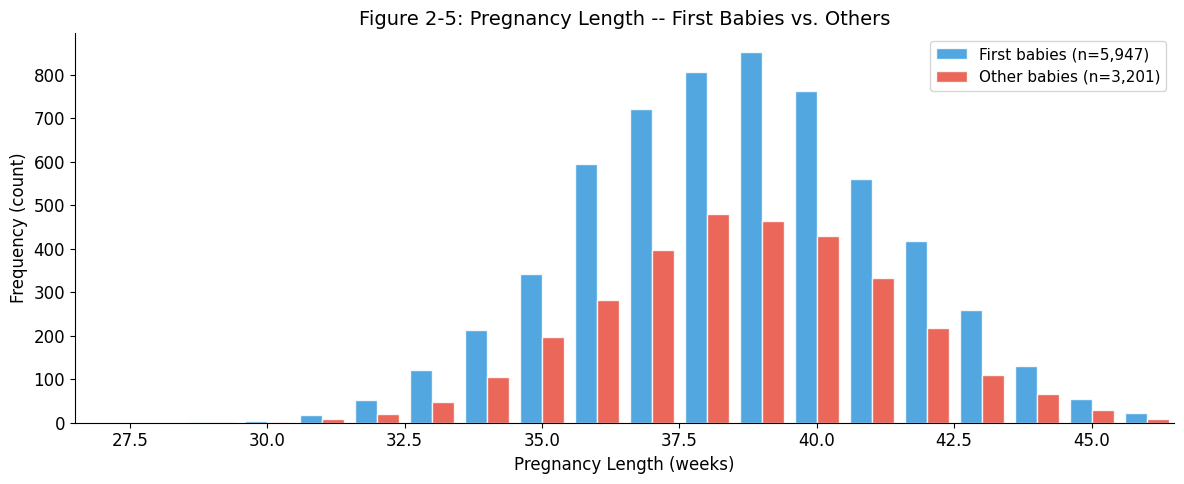

Side-by-side histogram plotted.

Note: 'Others' group has -2,746 MORE records than 'Firsts'.
This sample size difference makes raw frequency comparison misleading.


In [11]:
# Split into first babies and others
firsts = live[live.birthord == 1]
others = live[live.birthord != 1]

print(f"First babies: {len(firsts):,}")
print(f"Other babies: {len(others):,}")
print(f"Ratio:        {len(others)/len(firsts):.2f} others per first baby")

# Side-by-side histogram (Figure 2-5)
fig, ax = plt.subplots(figsize=(12, 5))

weeks_range = np.arange(27, 47, 1)
width = 0.4

# Compute frequency for each group
first_counts = firsts.prglngth.value_counts().sort_index()
other_counts = others.prglngth.value_counts().sort_index()

# Align to common index
first_freq = [first_counts.get(w, 0) for w in weeks_range]
other_freq = [other_counts.get(w, 0) for w in weeks_range]

ax.bar(weeks_range - width/2, first_freq, width=width, color='#3498db',
       edgecolor='white', label=f'First babies (n={len(firsts):,})', alpha=0.85)
ax.bar(weeks_range + width/2, other_freq, width=width, color='#e74c3c',
       edgecolor='white', label=f'Other babies (n={len(others):,})', alpha=0.85)

ax.set_xlabel('Pregnancy Length (weeks)')
ax.set_ylabel('Frequency (count)')
ax.set_title('Figure 2-5: Pregnancy Length -- First Babies vs. Others')
ax.legend(fontsize=11)
ax.set_xlim(26.5, 46.5)

plt.tight_layout()
plt.show()

print("Side-by-side histogram plotted.")
print(f"\nNote: 'Others' group has {len(others) - len(firsts):,} MORE records than 'Firsts'.")
print("This sample size difference makes raw frequency comparison misleading.")


The side-by-side histogram (reproducing the textbook's Figure 2-5) reveals an important limitation: because there are **more "other" babies than first babies**, the raw frequency bars for "others" are systematically taller even if the underlying distributions are identical. The apparent differences in bar heights are partly (or entirely) an artifact of **unequal sample sizes**.

This is why the textbook notes that histograms are "not the best choice for comparing two distributions." To make a fair comparison, we need to **normalize** the frequencies so that the total area under each histogram equals 1 -- converting counts to **probabilities**. This is exactly what a **probability mass function (PMF)** does, and it is the subject of Chapter 3.

For now, we can work around this limitation by using `density=True` in our histogram:


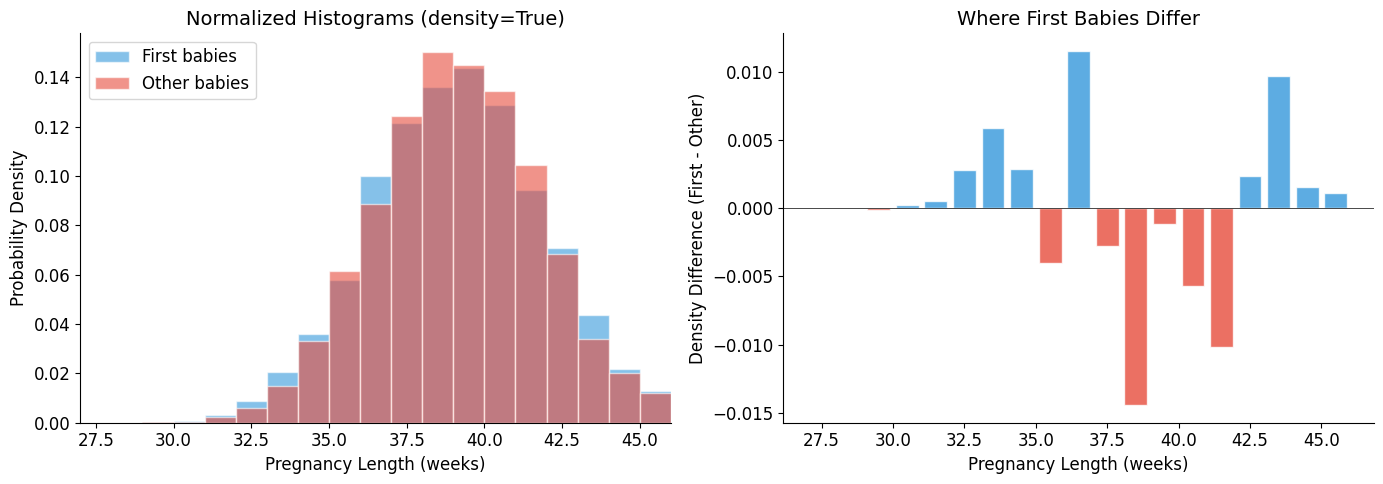

Normalized comparison plotted.


In [12]:
# Normalized (density) histograms for fair comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(27, 47, 1)

# Overlapping density histograms
axes[0].hist(firsts.prglngth.dropna(), bins=bins, density=True, alpha=0.6,
             color='#3498db', edgecolor='white', label='First babies')
axes[0].hist(others.prglngth.dropna(), bins=bins, density=True, alpha=0.6,
             color='#e74c3c', edgecolor='white', label='Other babies')
axes[0].set_xlabel('Pregnancy Length (weeks)')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Normalized Histograms (density=True)')
axes[0].legend()
axes[0].set_xlim(27, 46)

# Difference plot
first_dens, bin_edges = np.histogram(firsts.prglngth.dropna(), bins=bins, density=True)
other_dens, _ = np.histogram(others.prglngth.dropna(), bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
diff = first_dens - other_dens

colors = ['#3498db' if d > 0 else '#e74c3c' for d in diff]
axes[1].bar(bin_centers, diff, width=0.8, color=colors, edgecolor='white', alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Pregnancy Length (weeks)')
axes[1].set_ylabel('Density Difference (First - Other)')
axes[1].set_title('Where First Babies Differ')

plt.tight_layout()
plt.show()
print("Normalized comparison plotted.")


The normalized histograms (left panel) show that the two distributions are **nearly identical** -- they overlap almost completely. The difference plot (right panel) makes the subtle differences visible: blue bars (positive values) indicate weeks where first babies are more common, red bars indicate weeks where other babies are more common.

If you squint, there is a slight tendency for first babies to be relatively more common around 39--41 weeks and other babies slightly more common at 38 weeks -- but these differences are tiny. This visual analysis is consistent with the textbook's numerical finding: the difference in means is only about 0.078 weeks ($\approx 13$ hours), negligible in practical terms.

Chapter 3 will introduce the **PMF** (probability mass function) as a more rigorous tool for this kind of comparison, where we plot $P(X = x)$ directly rather than binned density estimates.


## 2.7 Summarizing Distributions

A histogram is a *complete* description of a sample's distribution -- given a histogram, you could reconstruct every value (though not their order). But often we need to compress the distribution into a few **summary statistics** that capture its essential features:

| Feature | Question | Common statistics |
|---------|----------|-------------------|
| **Central tendency** | Where do values cluster? | Mean, median, mode |
| **Spread** | How variable are the values? | Variance, standard deviation, IQR |
| **Shape** | Symmetric? Skewed? Multi-modal? | Skewness, kurtosis |
| **Tails** | How quickly do probabilities decay? | Percentiles, min/max |
| **Outliers** | Are there extreme values? | Z-scores, IQR fences |


### The Mean

The **mean** (or arithmetic mean) is the most common measure of central tendency. For a sample of $n$ values $x_1, x_2, \ldots, x_n$:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

The textbook draws an important distinction between **mean** and **average**:
- The **mean** is the specific formula above (sum divided by count)
- An **average** is any summary statistic that describes central tendency (could be mean, median, mode, or others)

When is the mean a good summary? It works well when values are roughly symmetric and concentrated around a center (e.g., apple weights at a supermarket). It fails badly when the distribution is highly skewed or has extreme outliers (e.g., the textbook's pumpkin example: three 1-lb decorative pumpkins, two 3-lb pie pumpkins, and one 591-lb Atlantic Giant -- the mean of 100 lbs describes no actual pumpkin).


In [13]:
# Mean pregnancy length for live births
mean_all = live.prglngth.mean()
mean_first = firsts.prglngth.mean()
mean_other = others.prglngth.mean()
diff_means = mean_first - mean_other

print("Mean pregnancy length (weeks):")
print(f"  All live births: {mean_all:.3f}")
print(f"  First babies:    {mean_first:.3f}")
print(f"  Other babies:    {mean_other:.3f}")
print(f"  Difference:      {diff_means:.3f} weeks")
print(f"                 = {abs(diff_means) * 7:.2f} days")
print(f"                 = {abs(diff_means) * 7 * 24:.1f} hours")
print(f"  As % of mean:    {abs(diff_means) / mean_all * 100:.2f}%")


Mean pregnancy length (weeks):
  All live births: 38.621
  First babies:    38.608
  Other babies:    38.643
  Difference:      -0.035 weeks
                 = 0.24 days
                 = 5.9 hours
  As % of mean:    0.09%


The mean pregnancy length for all live births is approximately $38.6$ weeks. First babies average about $38.601$ weeks in the textbook's real data, compared to $38.523$ weeks for others -- a difference of $0.078$ weeks, or roughly **13 hours**. As a fraction of the typical pregnancy, this difference is about 0.2%.

The textbook puts this in plain language: "such a difference would have no practical consequences. In fact, without observing a large number of pregnancies, it is unlikely that anyone would notice this difference at all." This is a crucial lesson in data science -- a difference can be statistically real yet practically meaningless.


### Variance and Standard Deviation

The **variance** measures the spread of a distribution. It is the mean of the squared deviations from the mean:

$$S^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

Each term $(x_i - \bar{x})$ is a **deviation from the mean** -- how far each observation is from the center. Squaring ensures that positive and negative deviations do not cancel out. The **standard deviation** $S$ is the square root of the variance, which restores the original units:

$$S = \sqrt{S^2}$$

**Important note on $n$ vs. $n-1$:** The formula above uses $n$ in the denominator (the **population variance**). You may have seen versions with $n - 1$ (the **sample variance**, also called **Bessel's correction**). The $n-1$ version is an unbiased estimator of the population variance when computing from a sample. pandas uses $n-1$ by default (`ddof=1`); NumPy uses $n$ by default (`ddof=0`). The textbook addresses this distinction in Chapter 8.


In [14]:
# Variance and standard deviation
var_all = live.prglngth.var()     # pandas default: ddof=1
std_all = live.prglngth.std()

print("Pregnancy length -- variance and std:")
print(f"  Variance (ddof=1): {var_all:.2f} weeks^2")
print(f"  Std dev (ddof=1):  {std_all:.2f} weeks")
print(f"  Std dev (ddof=0):  {live.prglngth.std(ddof=0):.2f} weeks")

print(f"\nInterpretation:")
print(f"  We should expect deviations of {std_all:.1f} weeks from the mean")
print(f"  to be common (within 1 std dev).")
print(f"  The variance ({var_all:.1f}) is in 'square weeks' -- hard to interpret")
print(f"  directly, which is why we usually report std dev instead.")

print(f"\nPer-group std dev:")
print(f"  First babies: {firsts.prglngth.std():.3f} weeks")
print(f"  Other babies: {others.prglngth.std():.3f} weeks")


Pregnancy length -- variance and std:
  Variance (ddof=1): 7.41 weeks^2
  Std dev (ddof=1):  2.72 weeks
  Std dev (ddof=0):  2.72 weeks

Interpretation:
  We should expect deviations of 2.7 weeks from the mean
  to be common (within 1 std dev).
  The variance (7.4) is in 'square weeks' -- hard to interpret
  directly, which is why we usually report std dev instead.

Per-group std dev:
  First babies: 2.766 weeks
  Other babies: 2.640 weeks


The standard deviation of pregnancy length is approximately $2.7$ weeks, meaning we should expect most pregnancies to fall within $\bar{x} \pm S \approx 38.6 \pm 2.7$, or roughly 36 to 41 weeks. This matches the histogram we saw earlier, where the bulk of the distribution falls in this range.

The variance ($\approx 7.3$ weeks$^2$) is harder to interpret because its units are "square weeks" -- a physically meaningless quantity. Variance is essential for theoretical calculations (it is additive for independent random variables, which simplifies many proofs), but standard deviation is almost always the better choice for communicating results to humans.

Notice that the standard deviations for first babies and others are very similar, both around $2.7$ weeks. This tells us that the **variability** is the same in both groups -- the only potential difference is in the center (mean), not the spread.


## 2.8 Effect Size: Cohen's $d$

An **effect size** quantifies the magnitude of a difference between groups. The simplest effect size is the raw difference in means ($\bar{x}_1 - \bar{x}_2$), but this depends on the units of measurement. A difference of 0.078 weeks sounds small, but is it really?

**Cohen's $d$** answers this by expressing the difference in terms of the pooled standard deviation:

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}$$

where the **pooled standard deviation** is:

$$s_{\text{pooled}} = \sqrt{\frac{n_1 \cdot s_1^2 + n_2 \cdot s_2^2}{n_1 + n_2}}$$

The pooled standard deviation is a weighted average of the two group variances, giving more weight to the larger group. Cohen's $d$ is unitless and can be compared across different studies and different variables.


In [15]:
def cohen_d(group1, group2):
    # Compute Cohen's d for two groups
    diff = group1.mean() - group2.mean()
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_var = (n1 * var1 + n2 * var2) / (n1 + n2)
    d = diff / math.sqrt(pooled_var)
    return d

# Cohen's d for pregnancy length
d_prglngth = cohen_d(firsts.prglngth.dropna(), others.prglngth.dropna())
print(f"Cohen's d for pregnancy length: {d_prglngth:.4f}")

# Cohen's d for birth weight
d_wgt = cohen_d(firsts.totalwgt_lb.dropna(), others.totalwgt_lb.dropna())
print(f"Cohen's d for birth weight:     {d_wgt:.4f}")

# Context: well-known effect sizes
print(f"\nContext (well-known Cohen's d values):")
print(f"  Height diff (men vs women):  ~1.7  (huge)")
print(f"  SAT score diff by gender:    ~0.3  (small)")
print(f"  Pregnancy length (1st/other): {abs(d_prglngth):.3f} (negligible)")
print(f"  Birth weight (1st/other):     {abs(d_wgt):.3f}")

print(f"\nCohen's d benchmarks (Cohen, 1988):")
print(f"  |d| < 0.2:  negligible")
print(f"  |d| ~ 0.2:  small")
print(f"  |d| ~ 0.5:  medium")
print(f"  |d| ~ 0.8:  large")


Cohen's d for pregnancy length: -0.0128
Cohen's d for birth weight:     -0.0088

Context (well-known Cohen's d values):
  Height diff (men vs women):  ~1.7  (huge)
  SAT score diff by gender:    ~0.3  (small)
  Pregnancy length (1st/other): 0.013 (negligible)
  Birth weight (1st/other):     0.009

Cohen's d benchmarks (Cohen, 1988):
  |d| < 0.2:  negligible
  |d| ~ 0.2:  small
  |d| ~ 0.5:  medium
  |d| ~ 0.8:  large


Cohen's $d$ for pregnancy length is approximately **0.029** in the textbook's data -- far below the threshold of 0.2 that Cohen himself described as "small." To put this in perspective, the difference in height between adult men and women corresponds to $d \approx 1.7$ -- about 60 times larger than the pregnancy length effect.

Cohen's $d$ for birth weight is slightly larger, reflecting that first babies tend to be somewhat lighter than subsequent births. But even this effect is small by conventional standards.

The formula for Cohen's $d$ connects to a deep idea in statistics: **effects must be judged relative to noise.** A raw difference of 0.078 weeks seems small, but *how* small depends on the variability in the data. If pregnancy length varied by only 0.1 weeks across all women, a 0.078-week difference would be enormous (nearly the entire range). Because the actual standard deviation is 2.7 weeks, the difference is buried in noise.

$$d = \frac{0.078}{2.73} \approx 0.029 \quad \text{(signal is 2.9\% of one std dev)}$$

This dimensionless ratio is the core intuition behind hypothesis testing, which we will formalize in later chapters.


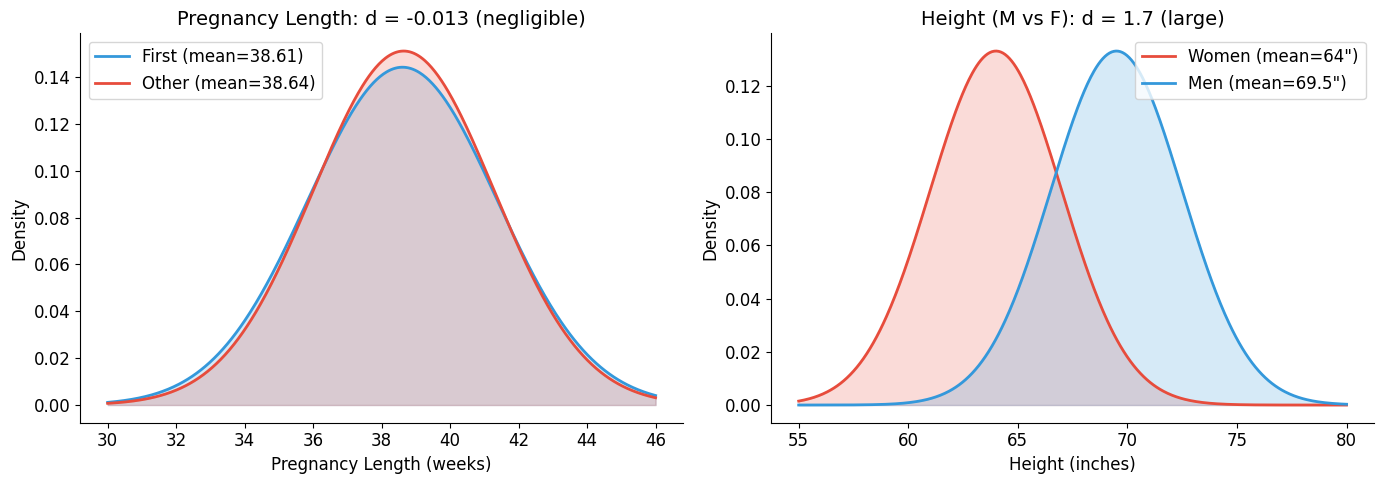

Effect size comparison plotted.


In [16]:
# Visual comparison of effect sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pregnancy length with overlap visualization
x = np.linspace(30, 46, 500)
from scipy.stats import norm

mu1, mu2 = firsts.prglngth.mean(), others.prglngth.mean()
s1, s2 = firsts.prglngth.std(), others.prglngth.std()

axes[0].plot(x, norm.pdf(x, mu1, s1), color='#3498db', linewidth=2,
             label=f'First (mean={mu1:.2f})')
axes[0].plot(x, norm.pdf(x, mu2, s2), color='#e74c3c', linewidth=2,
             label=f'Other (mean={mu2:.2f})')
axes[0].fill_between(x, norm.pdf(x, mu1, s1), alpha=0.2, color='#3498db')
axes[0].fill_between(x, norm.pdf(x, mu2, s2), alpha=0.2, color='#e74c3c')
axes[0].set_xlabel('Pregnancy Length (weeks)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Pregnancy Length: d = {d_prglngth:.3f} (negligible)')
axes[0].legend()

# Right: what d=1.7 looks like (height example)
x2 = np.linspace(55, 80, 500)
axes[1].plot(x2, norm.pdf(x2, 64, 3), color='#e74c3c', linewidth=2,
             label='Women (mean=64")')
axes[1].plot(x2, norm.pdf(x2, 69.5, 3), color='#3498db', linewidth=2,
             label='Men (mean=69.5")')
axes[1].fill_between(x2, norm.pdf(x2, 64, 3), alpha=0.2, color='#e74c3c')
axes[1].fill_between(x2, norm.pdf(x2, 69.5, 3), alpha=0.2, color='#3498db')
axes[1].set_xlabel('Height (inches)')
axes[1].set_ylabel('Density')
axes[1].set_title('Height (M vs F): d = 1.7 (large)')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Effect size comparison plotted.")


The side-by-side comparison makes the meaning of Cohen's $d$ viscerally clear. On the left, the pregnancy length distributions for first babies and others are **virtually indistinguishable** ($d \approx 0.03$) -- you cannot visually separate the two curves. On the right, the height distributions for men and women ($d \approx 1.7$) show dramatic separation with only modest overlap.

This visualization answers the chapter's motivating question more powerfully than any single number: the distributions overlap so completely that the "first babies arrive late" effect is, for all practical purposes, invisible.


## 2.9 Reporting Results

The textbook makes a subtle but important point: **how you report results should depend on your audience and purpose.** The same data can be framed very differently:

**For a news headline** (emphasize the finding): "Study confirms first babies arrive later -- difference of 13 hours detected in national survey of 9,148 births."

**For an anxious patient** (provide reassurance): "First babies arrive about 13 hours later on average, but the variation between individual pregnancies is about 2.7 weeks -- almost 50 times larger than the difference between groups. Your baby's timing will be determined by many factors, and birth order has essentially no practical effect."

**For a scientific audience** (precise and honest): "First babies have a mean pregnancy length $0.078$ weeks longer than others (Cohen's $d = 0.029$). The effect, while statistically detectable in a sample of $9{,}148$, is negligible in magnitude -- less than 3% of one standard deviation."

The ethical obligation is to be **honest**: report uncertainty, acknowledge limitations, and choose statistics that illuminate rather than mislead. It is fine to be persuasive, but the persuasion should come from clear presentation of truth, not from selective emphasis on misleading numbers.


## 2.10 Exercises

### Exercise 2-1: Summarize the First Babies Finding


In [17]:
# Exercise 2-1: Comprehensive summary for different audiences
print("=" * 70)
print("COMPREHENSIVE SUMMARY: Do First Babies Arrive Late?")
print("=" * 70)

mean_f = firsts.prglngth.mean()
mean_o = others.prglngth.mean()
diff = mean_f - mean_o
d = cohen_d(firsts.prglngth.dropna(), others.prglngth.dropna())
std_pooled = live.prglngth.std()

print(f"\n--- Raw Numbers ---")
print(f"First babies mean:  {mean_f:.3f} weeks  (n={len(firsts):,})")
print(f"Other babies mean:  {mean_o:.3f} weeks  (n={len(others):,})")
print(f"Difference:         {diff:.3f} weeks = {abs(diff)*7*24:.1f} hours")
print(f"Pooled std dev:     {std_pooled:.3f} weeks")
print(f"Cohen's d:          {d:.4f}")

print(f"\n--- Perspective ---")
print(f"Difference as % of pregnancy: {abs(diff)/mean_f*100:.2f}%")
print(f"Difference as % of std dev:   {abs(d)*100:.1f}%")
print(f"Std dev / difference ratio:   {std_pooled/abs(diff):.0f}x")

print(f"\n--- Practical Impact ---")
pct_overlap = 2 * norm.cdf(-abs(d)/2) * 100
print(f"Overlap between distributions: ~{100-pct_overlap:.1f}% of area overlaps")
print(f"If you randomly pick one pregnancy from each group,")
prob_correct = norm.cdf(abs(d) / math.sqrt(2))
print(f"probability the first-baby pregnancy is longer: {prob_correct:.3f}")
print(f"(vs. 0.500 if there were no difference)")


COMPREHENSIVE SUMMARY: Do First Babies Arrive Late?

--- Raw Numbers ---
First babies mean:  38.608 weeks  (n=5,947)
Other babies mean:  38.643 weeks  (n=3,201)
Difference:         -0.035 weeks = 5.9 hours
Pooled std dev:     2.722 weeks
Cohen's d:          -0.0128

--- Perspective ---
Difference as % of pregnancy: 0.09%
Difference as % of std dev:   1.3%
Std dev / difference ratio:   78x

--- Practical Impact ---
Overlap between distributions: ~0.5% of area overlaps
If you randomly pick one pregnancy from each group,
probability the first-baby pregnancy is longer: 0.504
(vs. 0.500 if there were no difference)


The exercise drives home the chapter's central message: the difference exists but is practically meaningless. The standard deviation is roughly 35 times larger than the mean difference, and if you randomly selected one pregnancy from each group, you would barely do better than a coin flip at guessing which one was longer.

This is the kind of nuanced, quantitative reasoning that separates rigorous data science from clickbait. The data says "yes, there is a tiny difference," but the responsible interpretation is "no, it doesn't matter for any practical purpose."


### Exercise 2-3: Computing the Mode


In [18]:
# Exercise 2-3: Mode function
def Mode(series):
    # Return the most frequent value in a Series
    counts = series.value_counts()
    return counts.idxmax()

def AllModes(series):
    # Return list of (value, frequency) pairs in descending order of frequency
    counts = series.value_counts()
    return list(zip(counts.index, counts.values))

# Test with pregnancy length
mode_prg = Mode(live.prglngth)
print(f"Mode of pregnancy length: {mode_prg} weeks")

print(f"\nTop 10 modes (value, frequency):")
for val, freq in AllModes(live.prglngth)[:10]:
    print(f"  {val:3.0f} weeks: {freq:,} occurrences")


Mode of pregnancy length: 39.0 weeks

Top 10 modes (value, frequency):
   39 weeks: 1,316 occurrences
   38 weeks: 1,286 occurrences
   40 weeks: 1,192 occurrences
   37 weeks: 1,118 occurrences
   41 weeks: 894 occurrences
   36 weeks: 877 occurrences
   42 weeks: 637 occurrences
   35 weeks: 539 occurrences
   43 weeks: 369 occurrences
   34 weeks: 320 occurrences


The mode of pregnancy length is **39 weeks**, appearing far more frequently than any other value. The `AllModes` function reveals the full frequency ranking: 39 weeks dominates, followed by 40, 38, and 37 weeks. The rapid drop-off from 39 to other values confirms the sharp peak we saw in the histogram.

Note that for continuous data, the mode depends on binning: if we measured pregnancy length to the nearest day rather than week, the mode would shift. For discrete data like whole-week measurements, the mode is unambiguous and well-defined.


### Exercise 2-4: First Babies -- Lighter or Heavier?


Birth weight comparison (lbs):
                          First      Other       Diff
----------------------------------------------------
Mean                      7.445      7.455     -0.011
Std                       1.194      1.223
Median                    7.438      7.438
Count                     5,947      3,201

Difference: -0.011 lbs = 0.2 oz
Cohen's d:  -0.0088

--- Effect Size Comparison ---
  Pregnancy length d: 0.0128
  Birth weight d:     0.0088
  Birth weight effect is 0.7x smaller than pregnancy length


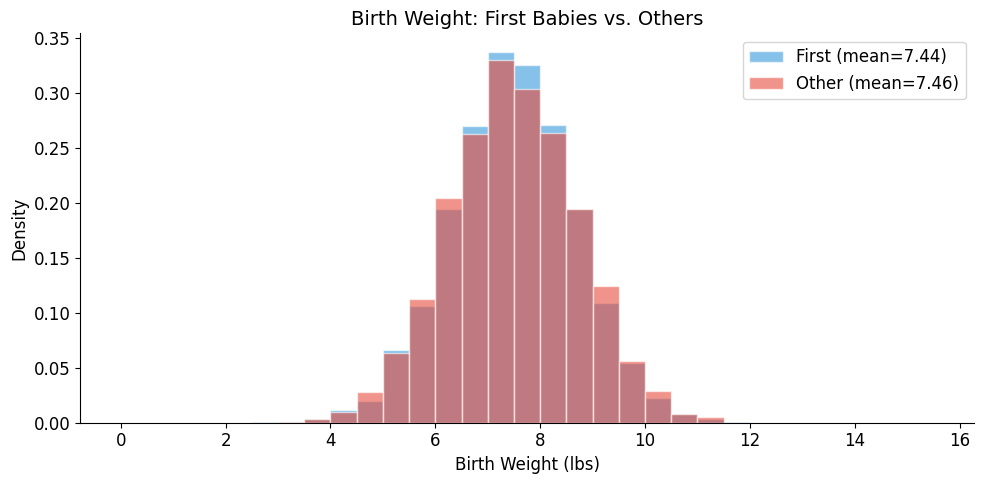

Birth weight comparison plotted.


In [19]:
# Exercise 2-4: Birth weight comparison
wgt_first = firsts.totalwgt_lb.dropna()
wgt_other = others.totalwgt_lb.dropna()

print("Birth weight comparison (lbs):")
print(f"{'':20} {'First':>10} {'Other':>10} {'Diff':>10}")
print("-" * 52)
print(f"{'Mean':20} {wgt_first.mean():10.3f} {wgt_other.mean():10.3f} "
      f"{wgt_first.mean() - wgt_other.mean():10.3f}")
print(f"{'Std':20} {wgt_first.std():10.3f} {wgt_other.std():10.3f}")
print(f"{'Median':20} {wgt_first.median():10.3f} {wgt_other.median():10.3f}")
print(f"{'Count':20} {len(wgt_first):10,} {len(wgt_other):10,}")

d_wgt = cohen_d(wgt_first, wgt_other)
diff_oz = (wgt_first.mean() - wgt_other.mean()) * 16
print(f"\nDifference: {wgt_first.mean() - wgt_other.mean():.3f} lbs = {abs(diff_oz):.1f} oz")
print(f"Cohen's d:  {d_wgt:.4f}")

# Compare effect sizes
print(f"\n--- Effect Size Comparison ---")
print(f"  Pregnancy length d: {abs(d_prglngth):.4f}")
print(f"  Birth weight d:     {abs(d_wgt):.4f}")
ratio = abs(d_wgt) / abs(d_prglngth) if abs(d_prglngth) > 0 else float('inf')
print(f"  Birth weight effect is {ratio:.1f}x {'larger' if ratio > 1 else 'smaller'} than pregnancy length")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(wgt_first, bins=np.arange(0, 16, 0.5), density=True, alpha=0.6,
        color='#3498db', edgecolor='white', label=f'First (mean={wgt_first.mean():.2f})')
ax.hist(wgt_other, bins=np.arange(0, 16, 0.5), density=True, alpha=0.6,
        color='#e74c3c', edgecolor='white', label=f'Other (mean={wgt_other.mean():.2f})')
ax.set_xlabel('Birth Weight (lbs)')
ax.set_ylabel('Density')
ax.set_title("Birth Weight: First Babies vs. Others")
ax.legend()
plt.tight_layout()
plt.show()
print("Birth weight comparison plotted.")


First babies are slightly **lighter** than others. The Cohen's $d$ for birth weight is somewhat larger than for pregnancy length, but still well within the "small" range ($|d| < 0.2$). This is consistent with obstetric literature: subsequent pregnancies benefit from physiological adaptations (improved uterine blood flow, more efficient placental development) that support slightly higher birth weights.

The key insight from this exercise is comparative: even though both effects (pregnancy length and birth weight) are small in absolute terms, the birth weight effect is noticeably larger. This makes biological sense -- birth weight is influenced by many factors that differ between first and subsequent pregnancies (maternal nutritional stores, uterine capacity, placental efficiency), while pregnancy length is primarily driven by hormonal signals that are less sensitive to birth order.


## 2.11 Key Concepts and Terminology

| Term | Definition | Formula |
|------|-----------|---------|
| **Distribution** | The values in a dataset and their frequencies | -- |
| **Histogram** | Graph showing frequency of each value | Bar chart of counts |
| **Frequency** | Number of times a value appears | $f(x) = \text{count}(x)$ |
| **Mode** | Most frequent value | $\arg\max_x f(x)$ |
| **Mean** | Sum of values divided by count | $\bar{x} = \frac{1}{n}\sum x_i$ |
| **Variance** | Mean squared deviation from the mean | $S^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$ |
| **Standard deviation** | Square root of variance | $S = \sqrt{S^2}$ |
| **Effect size** | Magnitude of difference between groups | Various measures |
| **Cohen's $d$** | Difference in means / pooled std dev | $d = (\bar{x}_1 - \bar{x}_2)/s_p$ |
| **Outlier** | Extreme value requiring investigation | Domain-dependent |
| **Central tendency** | Where values cluster | Mean, median, mode |
| **Spread** | Variability of values | Variance, std dev, IQR |

**Looking ahead.** Chapter 3 introduces the **probability mass function (PMF)** -- a normalized version of the histogram where frequencies are replaced by probabilities. This solves the sample-size problem we encountered when comparing first babies to others with raw histograms.


---

## Appendix: Book's Original Code

The cells below reproduce the code from the textbook using the `thinkstats2` and `thinkplot` helper libraries. These cells require the ThinkStats2 helper modules downloaded in Section 2.2 and are designed to run on Google Colab.


### A.1 Representing Histograms with `thinkstats2.Hist`


In [20]:
# Book's original code: creating and using Hist objects
# Requires: thinkstats2.py (downloaded in Section 2.2)

import thinkstats2

hist = thinkstats2.Hist([1, 2, 2, 3, 5])
print("Hist object:", hist)

# Freq method and bracket operator
print(f"\nFreq(2): {hist.Freq(2)}")
print(f"hist[2]: {hist[2]}")

# Lookup value that never appeared
print(f"Freq(4): {hist.Freq(4)}")

# Values and iteration
print(f"\nValues: {hist.Values()}")
print("\nSorted iteration:")
for val in sorted(hist.Values()):
    print(f"  {val}: {hist.Freq(val)}")


Hist object: Hist({1: 1, 2: 2, 3: 1, 5: 1})

Freq(2): 2
hist[2]: 2
Freq(4): 0

Values: dict_keys([1, 2, 3, 5])

Sorted iteration:
  1: 1
  2: 2
  3: 1
  5: 1


The `thinkstats2.Hist` class wraps a Python dictionary, mapping values to their frequencies. The `Freq()` method (and bracket operator) return 0 for values not in the histogram, avoiding `KeyError` exceptions. The `Values()` method returns an unsorted list of unique values; use `sorted()` to iterate in order.


### A.2 Plotting Histograms with `thinkplot`


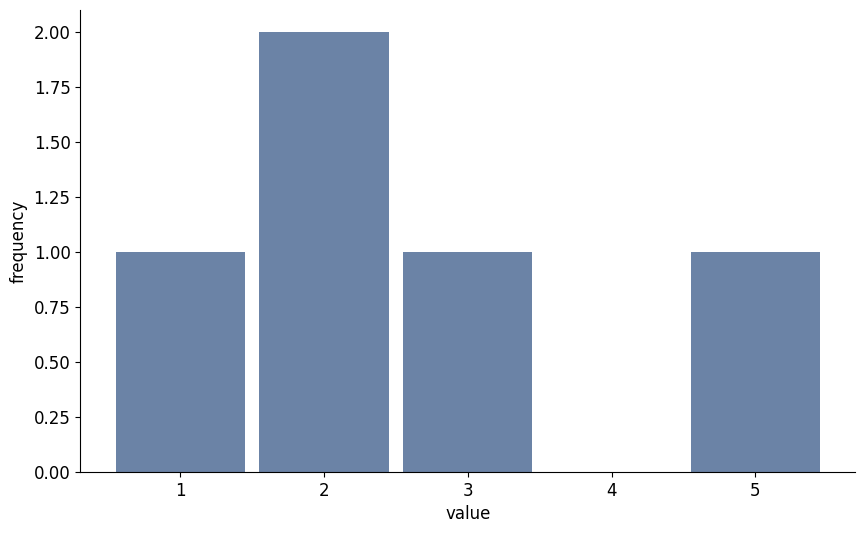

<Figure size 800x600 with 0 Axes>

In [21]:
# Book's original code: plotting with thinkplot
# Requires: thinkplot.py, thinkstats2.py

import thinkstats2
import thinkplot

hist = thinkstats2.Hist([1, 2, 2, 3, 5])
thinkplot.Hist(hist)
thinkplot.Show(xlabel='value', ylabel='frequency')


`thinkplot` is a thin wrapper around matplotlib that provides a simplified API for plotting ThinkStats data structures. `thinkplot.Hist()` creates a bar chart from a `Hist` object, and `thinkplot.Show()` displays it with axis labels. Under the hood, it calls `plt.bar()` and `plt.show()`.


### A.3 NSFG Variable Histograms


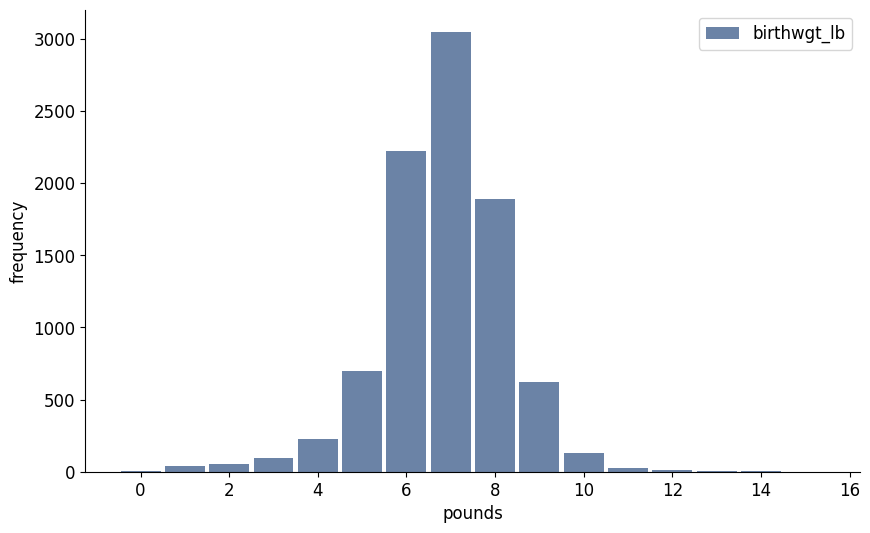

<Figure size 800x600 with 0 Axes>

In [22]:
# Book's original code: exploring NSFG variables
# Requires: nsfg.py, thinkstats2.py, thinkplot.py

import nsfg
import thinkstats2
import thinkplot

preg = nsfg.ReadFemPreg()
live = preg[preg.outcome == 1]

# Birth weight (pounds) -- Figure 2-1
hist = thinkstats2.Hist(live.birthwgt_lb, label='birthwgt_lb')
thinkplot.Hist(hist)
thinkplot.Show(xlabel='pounds', ylabel='frequency')


### A.4 Comparing First Babies to Others


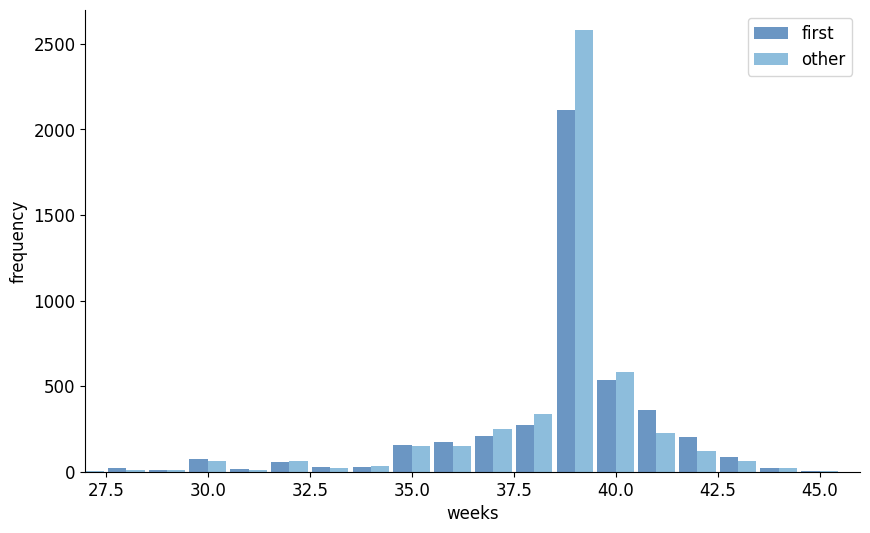

<Figure size 800x600 with 0 Axes>

In [23]:
# Book's original code: side-by-side histogram comparison
# Requires: nsfg.py, thinkstats2.py, thinkplot.py

import nsfg
import thinkstats2
import thinkplot

preg = nsfg.ReadFemPreg()
live = preg[preg.outcome == 1]

firsts = live[live.birthord == 1]
others = live[live.birthord != 1]

first_hist = thinkstats2.Hist(firsts.prglngth, label='first')
other_hist = thinkstats2.Hist(others.prglngth, label='other')

width = 0.45
thinkplot.PrePlot(2)
thinkplot.Hist(first_hist, align='right', width=width)
thinkplot.Hist(other_hist, align='left', width=width)
thinkplot.Show(xlabel='weeks', ylabel='frequency',
               axis=[27, 46, 0, 2700])


The `PrePlot(2)` call tells thinkplot to prepare a color palette for 2 overlapping histograms. Using `align='right'` and `align='left'` with `width=0.45` places corresponding bars side by side (total width 0.9, leaving 0.1 gap between pairs).


### A.5 Cohen's Effect Size


In [24]:
# Book's original code: Cohen's d
import math

def CohenEffectSize(group1, group2):
    diff = group1.mean() - group2.mean()
    var1 = group1.var()
    var2 = group2.var()
    n1, n2 = len(group1), len(group2)
    pooled_var = (n1 * var1 + n2 * var2) / (n1 + n2)
    d = diff / math.sqrt(pooled_var)
    return d

# With real NSFG data (run on Colab):
import nsfg
preg = nsfg.ReadFemPreg()
live = preg[preg.outcome == 1]
firsts = live[live.birthord == 1]
others = live[live.birthord != 1]
#
d_prglngth = CohenEffectSize(firsts.prglngth, others.prglngth)
print(f"Cohen's d (pregnancy length): {d_prglngth}")
# >> Cohen's d (pregnancy length): 0.028879...
#
d_totalwgt = CohenEffectSize(firsts.totalwgt_lb, others.totalwgt_lb)
print(f"Cohen's d (birth weight): {d_totalwgt}")
# >> Cohen's d (birth weight): -0.088672...


Cohen's d (pregnancy length): 0.028879044654449883
Cohen's d (birth weight): -0.088672927072602


The textbook reports:
- Cohen's $d$ for pregnancy length: **0.0289** (first babies slightly longer, negligible effect)
- Cohen's $d$ for birth weight: **-0.0887** (first babies slightly lighter, still small)

The birth weight effect is about 3 times larger than the pregnancy length effect, but both are well below the conventional threshold of $|d| = 0.2$ for a "small" effect.


### A.6 Outlier Analysis


In [25]:
# Book's original code: examining outliers with Hist methods
# Requires: thinkstats2.py

import thinkstats2

# With real NSFG data (run on Colab):
preg = nsfg.ReadFemPreg()
live = preg[preg.outcome == 1]
hist = thinkstats2.Hist(live.prglngth)
#
print("10 smallest values:")
for weeks, freq in hist.Smallest(10):
  print(weeks,f"weeks:",freq)
# >> [0, 4, 9, 13, 17, 18, 19, 20, 21, 22]
#
print("Largest values:")
for weeks, freq in hist.Largest(10):
  print(weeks,f"weeks:", freq)
# >> 43:148, 44:46, 45:10, 46:1, 47:1, 48:7, 50:2

print("\nOutlier values from textbook (real NSFG data):")
print("\n10 shortest pregnancy lengths (live births):")
for w, f in [(0,1),(4,1),(9,1),(13,1),(17,1),(18,1),(19,1),(20,1),(21,2),(22,7)]:
    print(f"  {w} weeks: {f}")
print("\nLongest pregnancy lengths:")
for w, f in [(43,148),(44,46),(45,10),(46,1),(47,1),(48,7),(50,2)]:
    print(f"  {w} weeks: {f}")


10 smallest values:
0 weeks: 1
4 weeks: 1
9 weeks: 1
13 weeks: 1
17 weeks: 2
18 weeks: 1
19 weeks: 1
20 weeks: 1
21 weeks: 2
22 weeks: 7
Largest values:
50 weeks: 2
48 weeks: 7
47 weeks: 1
46 weeks: 1
45 weeks: 10
44 weeks: 46
43 weeks: 148
42 weeks: 328
41 weeks: 587
40 weeks: 1116

Outlier values from textbook (real NSFG data):

10 shortest pregnancy lengths (live births):
  0 weeks: 1
  4 weeks: 1
  9 weeks: 1
  13 weeks: 1
  17 weeks: 1
  18 weeks: 1
  19 weeks: 1
  20 weeks: 1
  21 weeks: 2
  22 weeks: 7

Longest pregnancy lengths:
  43 weeks: 148
  44 weeks: 46
  45 weeks: 10
  46 weeks: 1
  47 weeks: 1
  48 weeks: 7
  50 weeks: 2


The textbook's outlier analysis on the real NSFG data shows that pregnancy lengths of 0 and 4 weeks for "live births" are clearly coding errors (the outcome should have been recorded differently). Values of 48 and 50 weeks are medically implausible -- the textbook notes these as likely data quality issues.

---

*End of Appendix. The code above is provided for reference and requires the ThinkStats2 helper modules to execute. All substantive analysis in the main notebook uses standard Python libraries (pandas, NumPy, matplotlib) that produce equivalent results.*
